# 04 — Integrated Human Capital Value Table + Segmentation

This notebook is the last step of our Deliverable 2 pipeline.

The idea is simple: we already created three KPI tables before:
- HR / performance KPIs
- absence KPIs
- training KPIs

Here, we put them together at employee level. Then we build a simple human capital value proxy and use clustering to create employee profiles.

Important: this is **not** a real financial valuation of employees. It is a first proxy based on the data we currently have.


## 0. Imports and file paths


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# This makes the notebook work whether it is run from the project root or from /notebooks
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Output folder:", OUTPUT_DIR)


Project root: c:\Users\nolwenn.montillot\Documents\PERSONAL\Albert School\Alberthon\CACEIS\caceis-human-capital-pipeline
Output folder: c:\Users\nolwenn.montillot\Documents\PERSONAL\Albert School\Alberthon\CACEIS\caceis-human-capital-pipeline\outputs


## 1. Load the three KPI output files

We now load the three CSV files created in the previous notebooks.

We also rename the employee identifier columns so that all tables use the same name: `employee_id`. This makes the merge easier and avoids mistakes.


In [35]:
hr = pd.read_csv(OUTPUT_DIR / "hr_kpi_table.csv", encoding="utf-8-sig")
absence = pd.read_csv(OUTPUT_DIR / "absence_kpi_table.csv", encoding="utf-8-sig")
training = pd.read_csv(OUTPUT_DIR / "training_kpi_table.csv", encoding="utf-8-sig")

# Standardize employee ID column names
hr = hr.rename(columns={"iug": "employee_id"})
absence = absence.rename(columns={"employee_code": "employee_id"})
training = training.rename(columns={"employee_code": "employee_id"})

# Make sure the low_data_flag is a proper boolean column
if "low_data_flag" in hr.columns:
    hr["low_data_flag"] = hr["low_data_flag"].fillna(False).astype(str).str.lower().eq("true")
else:
    hr["low_data_flag"] = False

print("HR table:", hr.shape)
print("Absence table:", absence.shape)
print("Training table:", training.shape)


HR table: (3765, 12)
Absence table: (2264, 6)
Training table: (2482, 6)


## 2. Check whether the files can be connected

Before merging the data, we check how many employees appear in several tables.

This matters because if very few IDs matched, we would not be able to build a reliable integrated table. Here, the overlap is large enough to continue, but we still keep data coverage flags later.


In [36]:
hr_ids = set(hr["employee_id"])
absence_ids = set(absence["employee_id"])
training_ids = set(training["employee_id"])

print("Employees in HR table:", len(hr_ids))
print("HR ∩ Absence:", len(hr_ids & absence_ids))
print("HR ∩ Training:", len(hr_ids & training_ids))
print("All three tables:", len(hr_ids & absence_ids & training_ids))


Employees in HR table: 3765
HR ∩ Absence: 1931
HR ∩ Training: 1854
All three tables: 1796


## 3. Build the integrated employee table

We use the HR table as the base table because it represents the main employee population. Then we add absence and training data with a left join.


In [50]:
employee = (
    hr.merge(absence, on="employee_id", how="left", indicator="absence_merge_status")
      .merge(training, on="employee_id", how="left", indicator="training_merge_status")
)

print("Integrated employee table:", employee.shape)
employee.head()


Integrated employee table: (3765, 24)


,employee_id,bu,libelle_emploi,type_contrat,country,libelle_organisation_niveau_07,avg_performance,performance_std,performance_reviews,low_data_flag,...,absence_events_score,absence_days_score,absenteeism_risk_score,absence_merge_status,training_count,training_hours,training_count_score,training_hours_score,learning_intensity_score,training_merge_status
0,ANON_65X48X48X48X48X50X51X54X48X55X50X,CACEIS,CHIEF COMPLIANCE OFFICER,CDI,France,Corporate Compliance,5.0,0.0,1.0,True,...,0.214664,0.214443,0.214532,both,2.0,63.00,0.351330,0.706487,0.528908,both
1,ANON_65X48X48X48X48X50X51X55X53X55X53X,CACEIS,GLOBAL HEAD,CDI,France,Risk & Permanent Controls,3.0,0.0,1.0,True,...,0.398410,0.305433,0.342624,both,1.0,14.00,0.154714,0.388799,0.271757,both
2,ANON_65X48X48X48X48X50X51X57X56X56X53X,CACEIS,GROUP HEAD,CDI,France,Enterprise Architecture,3.0,0.0,1.0,True,...,0.505521,0.545053,0.529240,both,8.0,65.00,0.778606,0.716761,0.747683,both
3,ANON_65X48X48X48X50X53X48X49X50X52X55X,CACEIS,GENERAL SECRETARY,CDI,France,General Secretary & Controls,3.0,0.0,1.0,True,...,0.348057,0.265018,0.298233,both,NaN,NaN,NaN,NaN,NaN,left_only
4,ANON_65X48X48X48X50X53X48X49X53X52X48X,CACEIS,IT PROJECT LEAD,CDI,France,IT Risks & CRM,4.0,0.0,1.0,True,...,0.532023,0.389576,0.446555,both,11.0,70.46,0.867446,0.739726,0.803586,both


## 4. Create data coverage flags

Not every employee has data in every source. So we create flags showing which records are available.

This helps us separate two things:
- a real low KPI score
- a missing KPI because the source data is not available


In [38]:
employee["has_absence_record"] = employee["absence_merge_status"].eq("both")
employee["has_training_record"] = employee["training_merge_status"].eq("both")
employee["has_performance_record"] = employee["avg_performance"].notna()

coverage = employee[["has_absence_record", "has_training_record", "has_performance_record"]].mean()
coverage


has_absence_record        0.512882
has_training_record       0.492430
has_performance_record    0.623373
dtype: float64

## 5. Fill missing KPI values carefully

For absence and training, if an employee has no record, we treat it as 0 for the first version of the prototype.

This is a simplification. In a real company setting, we would need to confirm whether missing means “no activity” or “not recorded”. That is why we also keep the coverage flags.


In [39]:
zero_fill_cols = [
    "absence_events", "absence_days", "absence_events_score", "absence_days_score",
    "absenteeism_risk_score", "training_count", "training_hours",
    "training_count_score", "training_hours_score", "learning_intensity_score"
]

for col in zero_fill_cols:
    if col in employee.columns:
        employee[col] = employee[col].fillna(0)

employee[zero_fill_cols].describe()


,absence_events,absence_days,absence_events_score,absence_days_score,absenteeism_risk_score,training_count,training_hours,training_count_score,training_hours_score,learning_intensity_score
count,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000
mean,30.114210,23.468260,0.279603,0.279945,0.279809,3.133333,29.394590,0.284636,0.280165,0.282401
std,46.012089,32.322196,0.330443,0.330713,0.329745,5.010114,52.608813,0.344715,0.346395,0.341267
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,9.000000,0.060954,0.069346,0.065989,0.000000,0.000000,0.000000,0.000000,0.000000
75%,48.000000,39.500000,0.558304,0.562058,0.559982,5.000000,40.000000,0.621676,0.595488,0.591861
max,428.000000,251.000000,1.000000,0.998454,0.997394,36.000000,1008.000000,1.000000,1.000000,0.998993


## 6. Build the Human Capital Value Proxy

This proxy combines four ideas:

1. **Performance**: current contribution, based on evaluation score.
2. **Talent progression**: internal growth potential, based on the existing HR KPI.
3. **Learning intensity**: future capability building, based on training activity.
4. **Absenteeism risk**: operational disruption risk, where lower risk improves the score.

The weights are simple and transparent. They are not final scientific weights. They are used to show how the method could work.


In [40]:
# Convert performance from a 1-5 scale to a 0-1 scale
employee["performance_score"] = employee["avg_performance"] / 5
employee["performance_score"] = employee["performance_score"].fillna(employee["performance_score"].median())

# Fill missing talent progression with the median
employee["talent_progression_proxy"] = employee["talent_progression_proxy"].fillna(employee["talent_progression_proxy"].median())

# Data coverage: how many of the three sources are available?
employee["data_coverage_score"] = employee[[
    "has_absence_record", "has_training_record", "has_performance_record"
]].mean(axis=1)

# KPI reliability: lower when performance data is weak or coverage is incomplete
employee["kpi_reliability_score"] = np.where(employee["low_data_flag"], 0.5, 1.0) * employee["data_coverage_score"]

# Human capital proxy score
employee["human_capital_value_proxy"] = (
    0.35 * employee["performance_score"]
    + 0.25 * employee["talent_progression_proxy"]
    + 0.20 * employee["learning_intensity_score"]
    + 0.20 * (1 - employee["absenteeism_risk_score"])
)

# Reliability-adjusted version, to penalize weak data coverage
employee["reliability_adjusted_value_proxy"] = (
    employee["human_capital_value_proxy"] * (0.5 + 0.5 * employee["kpi_reliability_score"])
)

employee[[
    "human_capital_value_proxy", 
    "reliability_adjusted_value_proxy", 
    "kpi_reliability_score"
]].describe()


,human_capital_value_proxy,reliability_adjusted_value_proxy,kpi_reliability_score
count,3765.000000,3765.000000,3765.000000
mean,0.550965,0.367708,0.307216
std,0.095215,0.117513,0.235444
min,0.258931,0.151043,0.000000
25%,0.468931,0.234465,0.000000
50%,0.538931,0.336779,0.333333
75%,0.623104,0.476471,0.500000
max,0.918400,0.650212,0.666667


## 7. Create simple risk and opportunity flags

The goal is not to make automatic HR decisions.

The goal is to create useful signals for a dashboard. These flags help identify cases where a manager or HR team may want to look more closely.


In [41]:
high_absence_cutoff = employee["absenteeism_risk_score"].quantile(0.80)
high_learning_cutoff = employee["learning_intensity_score"].quantile(0.80)
low_learning_cutoff = employee["learning_intensity_score"].quantile(0.20)
high_perf_cutoff = employee["performance_score"].quantile(0.80)
low_value_cutoff = employee["reliability_adjusted_value_proxy"].quantile(0.20)
high_value_cutoff = employee["reliability_adjusted_value_proxy"].quantile(0.80)

employee["risk_flag"] = np.select(
    [
        employee["absenteeism_risk_score"].ge(high_absence_cutoff),
        employee["reliability_adjusted_value_proxy"].le(low_value_cutoff),
        employee["low_data_flag"],
    ],
    [
        "High absenteeism risk",
        "Low value proxy",
        "Low KPI reliability",
    ],
    default="No major risk flag"
)

employee["opportunity_flag"] = np.select(
    [
        employee["performance_score"].ge(high_perf_cutoff) & employee["learning_intensity_score"].le(low_learning_cutoff),
        employee["learning_intensity_score"].ge(high_learning_cutoff) & employee["reliability_adjusted_value_proxy"].ge(high_value_cutoff),
    ],
    [
        "High performer with low training",
        "High value learning profile",
    ],
    default="No major opportunity flag"
)

employee[["risk_flag", "opportunity_flag"]].head()


,risk_flag,opportunity_flag
0,Low KPI reliability,No major opportunity flag
1,Low KPI reliability,No major opportunity flag
2,Low KPI reliability,No major opportunity flag
3,Low KPI reliability,No major opportunity flag
4,Low KPI reliability,High value learning profile


## 8. Exploratory analysis: value distribution

We now look at the distribution of the value proxy. This helps us see whether most employees have similar scores or whether the proxy separates employees into different groups.


In [42]:
employee["human_capital_value_proxy"].describe()


count    3765.000000
mean        0.550965
std         0.095215
min         0.258931
25%         0.468931
50%         0.538931
75%         0.623104
max         0.918400
Name: human_capital_value_proxy, dtype: float64

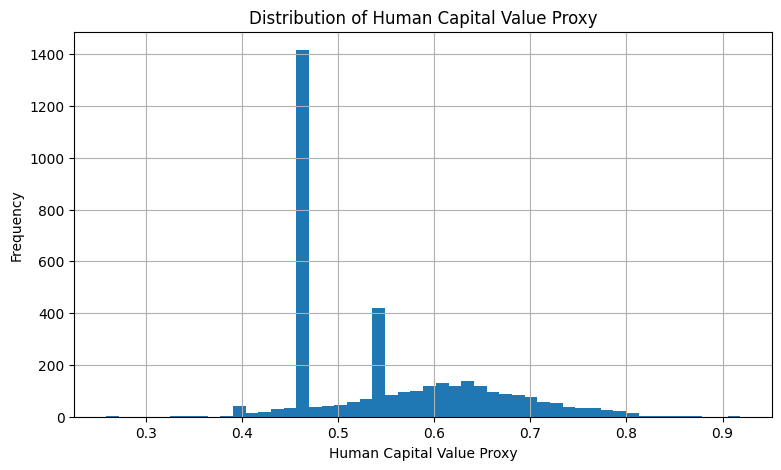

In [43]:
plt.figure(figsize=(9, 5))
employee["human_capital_value_proxy"].hist(bins=50)
plt.title("Distribution of Human Capital Value Proxy")
plt.xlabel("Human Capital Value Proxy")
plt.ylabel("Frequency")
plt.show()


### Interpretation

The graph shows a large concentration of employees around the middle of the score range. This means that for many employees, the current data does not strongly differentiate value.

At the same time, there is a smaller group with clearly higher scores and a small lower tail. For us, this means the proxy can identify some differences, but it is still limited by the quality and completeness of the available data.


## 9. Compare high-value and low-value employees

To understand the proxy better, we compare the top 50 and bottom 50 employees according to the value proxy.

This does not mean the bottom group is “bad”. It means the current data gives them a lower proxy score. That can happen because of lower KPIs, but also because of missing data.


In [44]:
top = employee.nlargest(50, "human_capital_value_proxy")
bottom = employee.nsmallest(50, "human_capital_value_proxy")

comparison = pd.DataFrame({
    "top_50": top.mean(numeric_only=True),
    "bottom_50": bottom.mean(numeric_only=True)
})

comparison.loc[[
    "avg_performance",
    "performance_score",
    "talent_progression_proxy",
    "training_count",
    "training_hours",
    "learning_intensity_score",
    "absence_events",
    "absence_days",
    "absenteeism_risk_score",
    "data_coverage_score",
    "kpi_reliability_score",
    "human_capital_value_proxy",
    "reliability_adjusted_value_proxy",
]]


,top_50,bottom_50
avg_performance,4.200000,1.891304
performance_score,0.840000,0.396000
talent_progression_proxy,0.735325,0.365620
training_count,14.320000,0.200000
training_hours,142.641600,0.720000
learning_intensity_score,0.879206,0.027266
absence_events,29.600000,48.520000
absence_days,24.450000,34.570000
absenteeism_risk_score,0.228734,0.243647
data_coverage_score,0.973333,0.433333


### Interpretation

The strongest difference is training. The top group has much higher training count, training hours, and learning intensity.

Performance also differs, but we should be careful because many employees only have one performance review. So performance alone is not enough to explain human capital value.

The bottom group also has weaker data coverage and lower KPI reliability. This is important because part of the “low value” result may come from missing or weak data, not only from actual employee performance.


## 10. AI segmentation with clustering

For the AI part, we use KMeans clustering.

Clustering is useful here because we do not have a target variable like “true value created”. Instead of predicting one outcome, the model groups employees with similar KPI patterns.

We use 3 clusters because it is simple enough to explain in the presentation and useful for a first prototype.


In [45]:
features = [
    "learning_intensity_score",
    "absenteeism_risk_score",
    "performance_score",
    "data_coverage_score",
]

X = employee[features].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
employee["ai_segment"] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, employee["ai_segment"])
print("Silhouette score:", round(sil_score, 3))


Silhouette score: 0.526


## 11. Understand the segments

Now we summarize the average KPI values for each segment.

The goal is to turn the model output into understandable employee profiles for the dashboard and presentation.


In [46]:
cluster_summary = employee.groupby("ai_segment").agg(
    employees=("employee_id", "nunique"),
    avg_performance=("avg_performance", "mean"),
    learning_intensity_score=("learning_intensity_score", "mean"),
    absenteeism_risk_score=("absenteeism_risk_score", "mean"),
    performance_score=("performance_score", "mean"),
    data_coverage_score=("data_coverage_score", "mean"),
    kpi_reliability_score=("kpi_reliability_score", "mean"),
    human_capital_value_proxy=("human_capital_value_proxy", "mean"),
    reliability_adjusted_value_proxy=("reliability_adjusted_value_proxy", "mean"),
).reset_index()

cluster_summary


,ai_segment,employees,avg_performance,learning_intensity_score,absenteeism_risk_score,performance_score,data_coverage_score,kpi_reliability_score,human_capital_value_proxy,reliability_adjusted_value_proxy
0,0,1233,2.907643,0.551288,0.585708,0.585888,0.902676,0.528521,0.581764,0.445385
1,1,1942,3.360736,0.015820,0.010710,0.630278,0.184518,0.112599,0.492127,0.276417
2,2,590,4.054237,0.597930,0.526275,0.810847,0.970621,0.485311,0.680265,0.505861


## 12. Name the segments

Based on the cluster summary, we give each group a business name.

These names are only for interpretation. They should not be used as labels for judging employees. They are meant to help HR and managers understand patterns.


In [47]:
# These names are based on the observed cluster averages in our run.
# If the clustering changes later, the names should be checked again.
segment_names = {
    0: "Low information / low learning",
    1: "Engaged but at risk",
    2: "High performers / low development",
}

employee["segment_name"] = employee["ai_segment"].map(segment_names)
cluster_summary["segment_name"] = cluster_summary["ai_segment"].map(segment_names)

cluster_summary[[
    "ai_segment",
    "segment_name",
    "employees",
    "learning_intensity_score",
    "absenteeism_risk_score",
    "performance_score",
    "data_coverage_score",
    "human_capital_value_proxy",
]]


,ai_segment,segment_name,employees,learning_intensity_score,absenteeism_risk_score,performance_score,data_coverage_score,human_capital_value_proxy
0,0,Low information / low learning,1233,0.551288,0.585708,0.585888,0.902676,0.581764
1,1,Engaged but at risk,1942,0.015820,0.010710,0.630278,0.184518,0.492127
2,2,High performers / low development,590,0.597930,0.526275,0.810847,0.970621,0.680265


### Interpretation of the segments

**Segment 0 — Low information / low learning**  
This is a large group with low learning activity and weak data coverage. The main recommendation is to improve data collection before making strong conclusions.

**Segment 1 — Engaged but at risk**  
This group has high learning intensity but also high absenteeism. This could point to employees who are active and developing, but who may also face workload or well-being risks.

**Segment 2 — High performers / low development**  
This smaller group has strong performance but low learning activity. The opportunity is to protect and develop these employees so their skills continue to grow.


## 13. Department-level summary

Finally, we create a department summary. This helps move from individual employee data to team-level insights, which is safer and more useful for HR decision-making.


In [48]:
dept_col = "libelle_organisation_niveau_07"

if dept_col in employee.columns:
    department_summary = (
        employee.groupby(dept_col, dropna=False)
        .agg(
            employees=("employee_id", "nunique"),
            avg_value_proxy=("human_capital_value_proxy", "mean"),
            avg_reliability_adjusted_value=("reliability_adjusted_value_proxy", "mean"),
            avg_absenteeism_risk=("absenteeism_risk_score", "mean"),
            avg_learning_intensity=("learning_intensity_score", "mean"),
            avg_kpi_reliability=("kpi_reliability_score", "mean"),
            high_absence_risk_share=("risk_flag", lambda s: (s == "High absenteeism risk").mean()),
        )
        .reset_index()
        .sort_values("employees", ascending=False)
    )
else:
    department_summary = pd.DataFrame()
    print("Department column not found:", dept_col)

department_summary.head()


,libelle_organisation_niveau_07,employees,avg_value_proxy,avg_reliability_adjusted_value,avg_absenteeism_risk,avg_learning_intensity,avg_kpi_reliability,high_absence_risk_share
74,Funds NAV Calculation,318,0.577235,0.430852,0.567662,0.402192,0.487421,0.430818
42,Custody Services,281,0.574316,0.426440,0.499653,0.374285,0.479834,0.412811
70,Fund Administration,255,0.484825,0.270687,0.006978,0.006058,0.114379,0.007843
149,PERES Operations FA,204,0.552850,0.372515,0.275022,0.282149,0.319444,0.176471
62,FDS Operations,150,0.511778,0.322340,0.224524,0.152268,0.245556,0.186667


## 14. Export final output files

We save the final employee-level table and summaries to the `outputs` folder so they can be used in the dashboard and in the presentation.


In [49]:
employee.to_csv(OUTPUT_DIR / "employee_value_table_v2.csv", index=False, encoding="utf-8-sig")
cluster_summary.to_csv(OUTPUT_DIR / "ai_segment_summary_v2.csv", index=False, encoding="utf-8-sig")

if not department_summary.empty:
    department_summary.to_csv(OUTPUT_DIR / "department_value_summary_v2.csv", index=False, encoding="utf-8-sig")

print("Saved:")
print("- employee_value_table_v2.csv")
print("- ai_segment_summary_v2.csv")
print("- department_value_summary_v2.csv")


Saved:
- employee_value_table_v2.csv
- ai_segment_summary_v2.csv
- department_value_summary_v2.csv


## 15. Main findings from this notebook

1. We were able to build an integrated employee-level table from HR, absence, and training KPIs.

2. The human capital value proxy shows differences between employees, but the score is still affected by data availability.

3. Learning intensity is one of the clearest differences between high-value and low-value profiles.

4. Performance data alone is not enough because many employees only have one review.

5. The clustering model gives three simple workforce profiles that can be used in the dashboard: low-information employees, engaged but at-risk employees, and high performers with low development activity.

These results are useful for Deliverable 2 because they show the pipeline is working and they create a base for the final AI-powered prototype.
